In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# loading dataset
data = load_breast_cancer()
X, y = data.data, data.target
X.shape, y.shape

((569, 30), (569,))

In [3]:
X[0]

array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
       3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
       8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
       3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
       1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01])

In [4]:
y[0]

np.int64(0)

In [5]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [6]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# defining model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # Input
    layers.Dense(32, activation="relu"), # layer 1 with 32 neurons
    layers.Dropout(0.3), # 30% of neurons in the previous layer are randomly turned off during each training step
    layers.Dense(16, activation="relu"), # layer 2 with 16 neurons
    layers.Dense(1, activation="sigmoid")  # layer 3 with 1 neuron
])

In [9]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [10]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7170 - loss: 0.5819 - val_accuracy: 0.9011 - val_loss: 0.4272
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9368 - loss: 0.3425 - val_accuracy: 0.9231 - val_loss: 0.2771
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9505 - loss: 0.2367 - val_accuracy: 0.9560 - val_loss: 0.2025
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9478 - loss: 0.1902 - val_accuracy: 0.9560 - val_loss: 0.1611
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9615 - loss: 0.1515 - val_accuracy: 0.9670 - val_loss: 0.1310
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9753 - loss: 0.1209 - val_accuracy: 0.9670 - val_loss: 0.1111
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9698 - loss: 0.1151 - val_accuracy: 0.9670 - val_loss: 0.0988
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9808 - loss: 0.0968 - val_accuracy: 0.9670 - val_loss

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9561


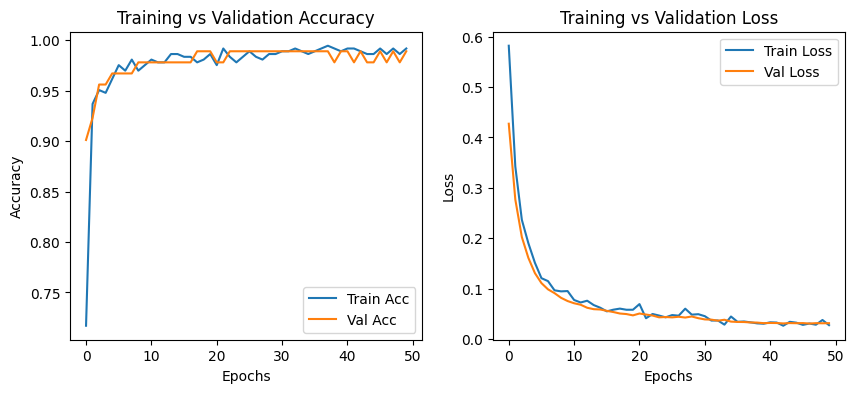

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# plotting accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# plotting loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

#### Assignment
- Train a feed-forward neural network to solve a multi-class classification task. You can use a dataset of your choice from scikit-learn or kaggle. Use the ``Weights and Biases`` Python library for visualization during model training, and take screenshots of your dashboard. Compute relevant performance metrics and save your model.
- Use the PyTorch Python library to train a feedforward neural network to solve a regression task. You can use a dataset of your choice. Implement checkpointing and earlystopping. Compute relevant performance metrics and save your best model